In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import random

In [6]:
data = pd.read_csv('/content/Electricity+Demand+Dataset.csv')


In [7]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [9]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'], format='%d-%b-%y')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43848 non-null  datetime64[ns]
 1   hour         43837 non-null  float64       
 2   dayofweek    43839 non-null  float64       
 3   month        43840 non-null  float64       
 4   year         43843 non-null  float64       
 5   dayofyear    43843 non-null  float64       
 6   Temperature  43841 non-null  float64       
 7   Humidity     43838 non-null  float64       
 8   Demand       43841 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.0 MB


In [11]:
data= data.set_index('Timestamp')

In [12]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [13]:
data[['Temperature','Humidity','Demand']].describe()

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


In [14]:
data.isnull().sum()

,0
hour,11
dayofweek,9
month,8
year,5
dayofyear,5
Temperature,7
Humidity,10
Demand,7


In [15]:
data[data.isna().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [16]:
data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
data=data.dropna(how='all')
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [18]:
data.isnull().sum()

,0
hour,7
dayofweek,5
month,4
year,1
dayofyear,1
Temperature,3
Humidity,6
Demand,3


In [19]:
data[['hour',	'dayofweek',	'month'	,'year'	,'dayofyear']]=data[['hour',	'dayofweek',	'month'	,'year'	,'dayofyear']].ffill()
data

/tmp/ipykernel_3922/219839487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['hour',	'dayofweek',	'month'	,'year'	,'dayofyear']]=data[['hour',	'dayofweek',	'month'	,'year'	,'dayofyear']].ffill()


,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [20]:
data[['Humidity'	,'Temperature']]=data[['Humidity'	,'Temperature']].bfill()
data


/tmp/ipykernel_3922/716618913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['Humidity'	,'Temperature']]=data[['Humidity'	,'Temperature']].bfill()


,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [21]:
data['Demand']=data['Demand'].interpolate(method='time')
data

/tmp/ipykernel_3922/803969720.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Demand']=data['Demand'].interpolate(method='time')


,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [22]:
data.isnull().sum()

,0
hour,0
dayofweek,0
month,0
year,0
dayofyear,0
Temperature,0
Humidity,0
Demand,0


In [23]:
data.insert(5, 'quater',data.index.quarter)

In [24]:
data

,hour,dayofweek,month,year,dayofyear,quater,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [25]:
data[['hour',	'dayofweek',	'month'	,'year'	,'dayofyear']]=data[['hour',	'dayofweek',	'month'	,'year'	,'dayofyear']].astype(int)


/tmp/ipykernel_3922/3291918630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['hour',	'dayofweek',	'month'	,'year'	,'dayofyear']]=data[['hour',	'dayofweek',	'month'	,'year'	,'dayofyear']].astype(int)


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  int64  
 1   dayofweek    43844 non-null  int64  
 2   month        43844 non-null  int64  
 3   year         43844 non-null  int64  
 4   dayofyear    43844 non-null  int64  
 5   quater       43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(3), int32(1), int64(5)
memory usage: 3.2 MB


In [27]:
data

,hour,dayofweek,month,year,dayofyear,quater,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,4,3.000000,40.565916,4015.979957


In [28]:
data.insert(5,'weekofyear', data.index.isocalendar().week.astype(int))

In [29]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,3.000000,40.565916,4015.979957


In [30]:
data.tail(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2024-12-29,22,6,12,2024,364,52,4,3.000000,70.021729,2929.747277
2024-12-29,23,6,12,2024,364,52,4,3.000000,52.836009,2668.369837
2024-12-30,0,0,12,2024,365,1,4,3.000000,65.892957,2699.075526
2024-12-30,1,0,12,2024,365,1,4,3.000000,72.128006,2644.045970
2024-12-30,2,0,12,2024,365,1,4,3.000000,68.631804,2206.527443
2024-12-30,3,0,12,2024,365,1,4,5.018972,78.981498,2414.881030
2024-12-30,4,0,12,2024,365,1,4,3.000000,70.592472,2473.705275
2024-12-30,5,0,12,2024,365,1,4,7.835546,74.624102,3291.585334
2024-12-30,6,0,12,2024,365,1,4,11.118482,68.974585,4120.280932


In [31]:
data.insert(7,'is_weekend',data.index.dayofweek.isin([5,6]))

In [32]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,False,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,False,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,False,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,False,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,False,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,False,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,False,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,False,3.000000,40.565916,4015.979957


In [33]:
data['is_weekend']=data['is_weekend'].astype(int)

/tmp/ipykernel_3922/608940048.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['is_weekend']=data['is_weekend'].astype(int)


In [34]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


In [35]:
data[data['is_weekend']==1]

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-04,0,5,1,2020,4,1,1,1,3.000000,60.955363,2067.352696
2020-01-04,1,5,1,2020,4,1,1,1,3.000000,66.494073,2138.504702
2020-01-04,2,5,1,2020,4,1,1,1,3.000000,56.398199,1880.418696
2020-01-04,3,5,1,2020,4,1,1,1,4.474526,60.603500,2005.823854
2020-01-04,4,5,1,2020,4,1,1,1,7.738184,65.808825,2203.720413
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,19,6,12,2024,364,52,4,1,7.077721,46.341323,4304.049396
2024-12-29,20,6,12,2024,364,52,4,1,3.000000,69.641621,4146.583958
2024-12-29,21,6,12,2024,364,52,4,1,3.723222,46.751731,3366.641206


In [36]:
import holidays

In [37]:
data['holidays']=holidays.IN(years=data.year)

/tmp/ipykernel_3922/1149258235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['holidays']=holidays.IN(years=data.year)


In [38]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand,holidays
Timestamp,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,NaN
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,NaN
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,NaN


In [39]:
data=data.drop('holidays',axis=1)

In [40]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


In [41]:
data['demand_lag_24hr']=data['Demand'].shift(24)

In [42]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand,demand_lag_24hr
Timestamp,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701


In [43]:
data['demand_lag_168hr']=data['Demand'].shift(160)

In [44]:
data.iloc[168:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand,demand_lag_24hr,demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,4575.159503
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,4512.169696
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,4622.245785
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,4240.094906
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,4439.240300
2020-01-08,5,2,1,2020,8,2,1,0,11.228013,73.962977,3372.983284,3113.810048,4758.538052
2020-01-08,6,2,1,2020,8,2,1,0,7.224730,71.773393,3638.748816,3794.729270,4457.071914
2020-01-08,7,2,1,2020,8,2,1,0,17.710862,48.828914,4650.003446,4285.030093,4393.986282
2020-01-08,8,2,1,2020,8,2,1,0,14.323524,68.049498,4580.866193,4470.762678,4730.327617


In [49]:
data['demand_rolling_mean_24hr']=data['Demand'].rolling(window=24).mean()

In [50]:
data['demand_rolling_Std_24hr']=data['Demand'].rolling(window=24).std()

In [51]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand,demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_Std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,2489.424695,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,2544.193224,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3292.725727,4052.475170,977.565114


In [52]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand,demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_Std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,2489.424695,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,2544.193224,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3292.725727,4052.475170,977.565114


In [53]:
data=data.dropna()

In [54]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quater,is_weekend,Temperature,Humidity,Demand,demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_Std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-07,16,1,1,2020,7,2,1,0,14.016616,37.637752,4587.785143,4733.816549,2457.119872,3850.341646,967.346084
2020-01-07,17,1,1,2020,7,2,1,0,6.736632,54.734906,4833.704288,4796.039663,2269.904712,3851.911005,968.976208
2020-01-07,18,1,1,2020,7,2,1,0,17.782435,49.297649,5400.257796,4791.518998,2215.640403,3877.275122,1002.043933
2020-01-07,19,1,1,2020,7,2,1,0,3.000000,37.696671,4424.534926,4492.165854,2174.232413,3874.457166,1000.333186
2020-01-07,20,1,1,2020,7,2,1,0,7.116704,46.152197,4279.454320,4398.302015,2472.453006,3869.505179,997.918482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,2489.424695,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,2544.193224,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3292.725727,4052.475170,977.565114


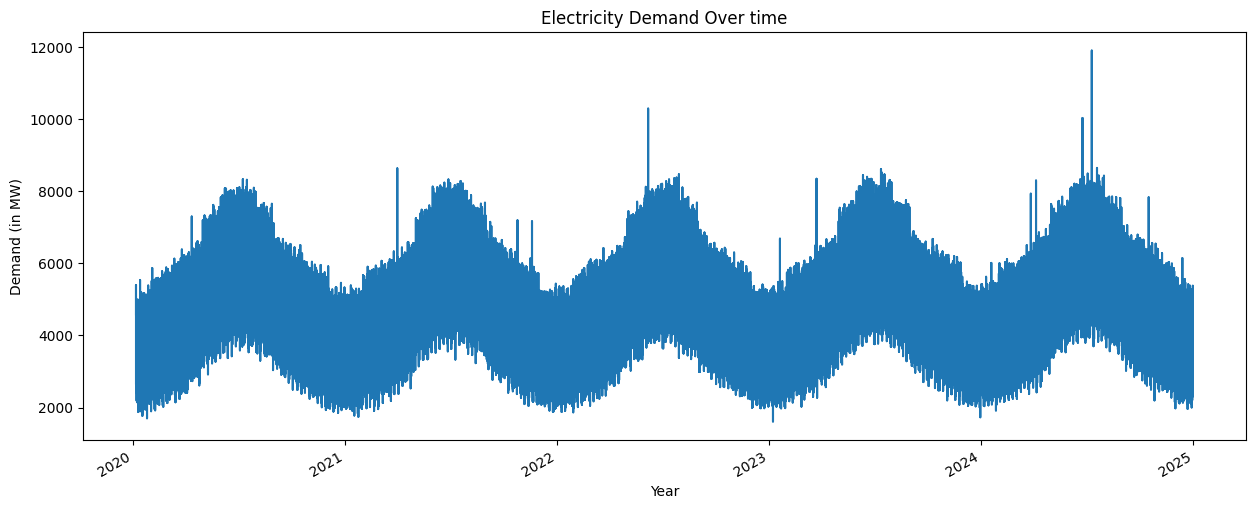

In [56]:
data['Demand'].plot(figsize=(15,6),title='Electricity Demand Over time')
plt.xlabel('Year')
plt.ylabel('Demand (in MW)')
plt.show()

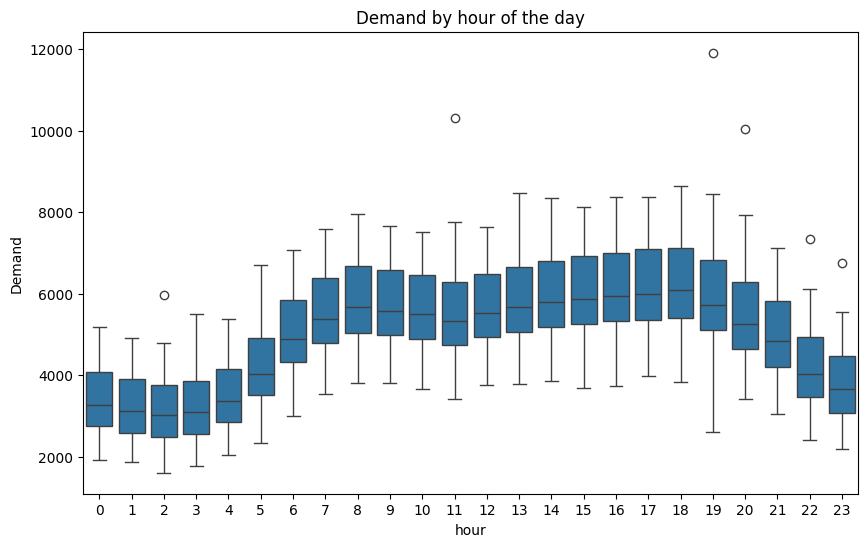

In [59]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='hour',y='Demand')
plt.title('Demand by hour of the day');


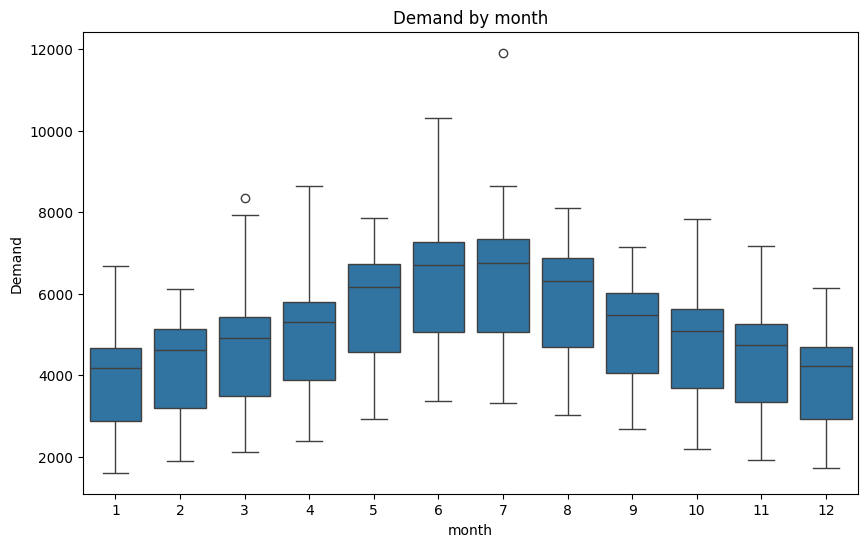

In [61]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='month',y='Demand')
plt.title('Demand by month');

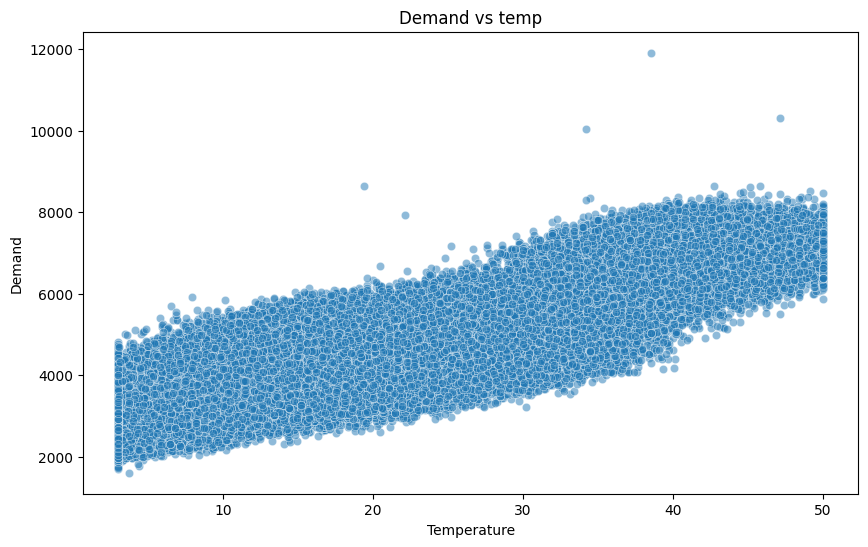

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data,x='Temperature',y='Demand',alpha=0.5)
plt.title('Demand vs temp');

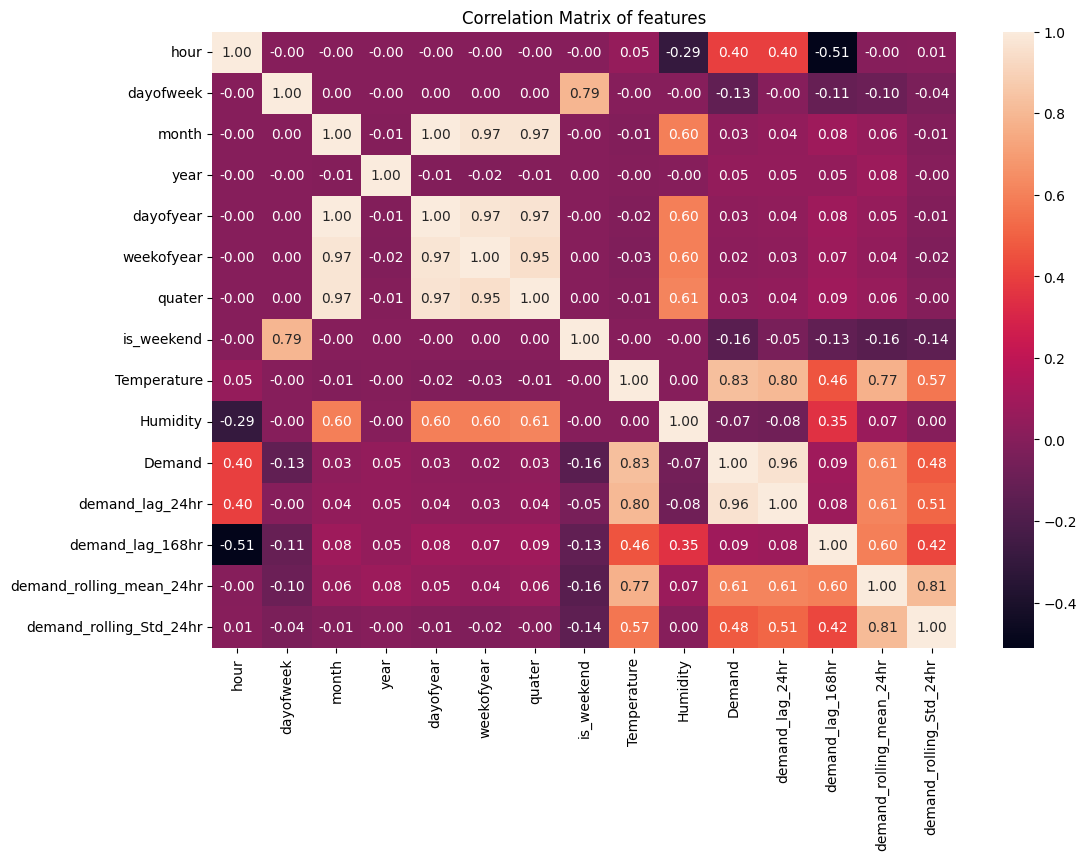

In [75]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(),annot=True,fmt='.2f')
plt.title('Correlation Matrix of features');


In [77]:
Y = data.Demand

In [78]:
X= data.drop('Demand',axis=1)

In [79]:
print(Y)

Timestamp
2020-01-07    4587.785143
2020-01-07    4833.704288
2020-01-07    5400.257796
2020-01-07    4424.534926
2020-01-07    4279.454320
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 43684, dtype: float64


In [80]:
print(X)

            hour  dayofweek  month  year  dayofyear  weekofyear  quater  \
Timestamp                                                                 
2020-01-07    16          1      1  2020          7           2       1   
2020-01-07    17          1      1  2020          7           2       1   
2020-01-07    18          1      1  2020          7           2       1   
2020-01-07    19          1      1  2020          7           2       1   
2020-01-07    20          1      1  2020          7           2       1   
...          ...        ...    ...   ...        ...         ...     ...   
2024-12-31    19          1     12  2024        366           1       4   
2024-12-31    20          1     12  2024        366           1       4   
2024-12-31    21          1     12  2024        366           1       4   
2024-12-31    22          1     12  2024        366           1       4   
2024-12-31    23          1     12  2024        366           1       4   

            is_weekend  

In [81]:
X_train=X.loc[:'2023-12-31']

In [82]:
Y_train=Y.loc[:'2023-12-31']

In [83]:
X_test=X.loc['2024-01-01':]

In [84]:
Y_test=Y.loc['2024-01-01':]

In [85]:
print(X_train.shape)

(34900, 14)


In [86]:
print(Y_train.shape)

(34900,)


In [87]:
print(X_test.shape)

(8784, 14)


In [88]:
print(Y_test.shape)

(8784,)


In [92]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [95]:
model_xgb=XGBRegressor(n_estimators=1000,
                       early_stopping_round=50,
                       learning_rate=0.01,
                       random_state=42,
                       objective='reg:squarederror'
                       )

In [96]:
model_xgb.fit(X_train,Y_train,eval_set=[(X_train,Y_train),(X_test,Y_test)],verbose=False)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:56:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "early_stopping_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_round=50,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None, ...)

In [97]:
prediction_xgb=model_xgb.predict(X_test)

In [101]:
rmse_xgb=np.sqrt(mean_squared_error(Y_test,prediction_xgb))
mae_xgb=mean_absolute_error(Y_test,prediction_xgb)
print("RMSE" ,rmse_xgb)
print("MAE" ,mae_xgb)

RMSE 175.9728459738139
MAE 122.87827339659732


Text(0.5, 1.0, 'Actual vs Predicted Demand')

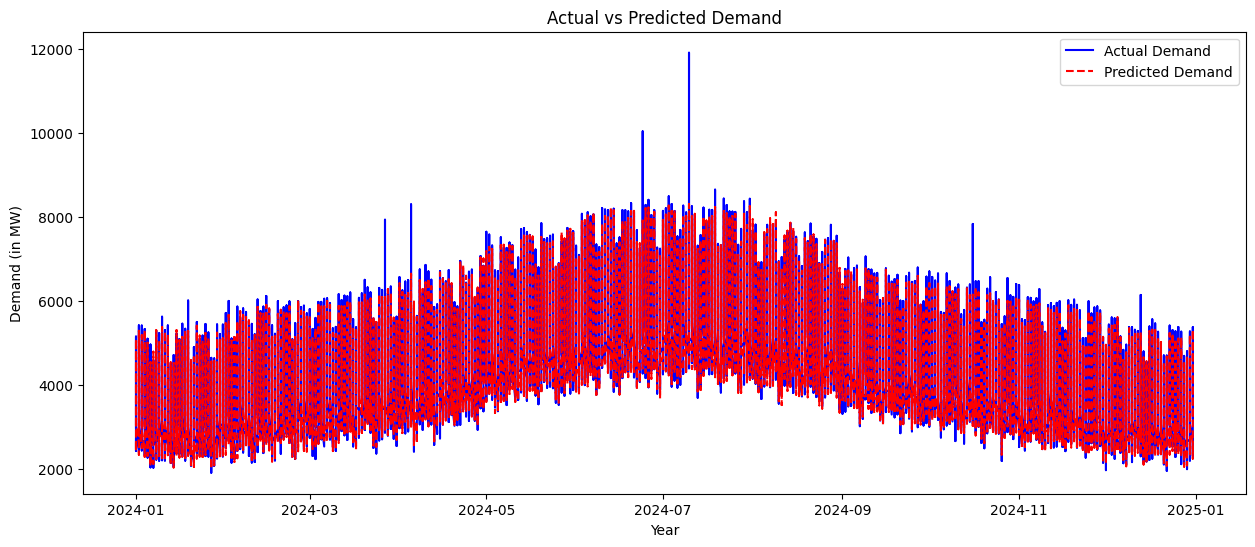

In [108]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(15,6))
plt.plot(Y_test.index,Y_test,label="Actual Demand",color='blue')
plt.plot(Y_test.index,prediction_xgb,label="Predicted Demand",color='red', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Demand (in MW)')
plt.legend()
plt.title('Actual vs Predicted Demand')

In [110]:
import joblib
joblib.dump(model_xgb, 'Electricity_Xgb_prediction_model.pkl')

['Electricity_Xgb_prediction_model.pkl']